In [3]:
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.append(project_root)

# Dataset generation

Main idea: 
- Crear un dataset de propiedades dentro de distritos de lima.
- 3 propiedades por distrito
- Crear un prompt para cada propiedad. 
- Este prompt se traduce en una clase pydantic.
- La clase pydantic se traduce en un QUERY de OpenSearch
- El query de OpenSearch se traduce en un resultado. 
- Se usará metrica recall@k

## Coordinates based generation using pandas

In [2]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

In [2]:
shp_path = Path.cwd().parent.parent / "data-gen" / "data" / "Distrital INEI 2023 geogpsperu SuyoPomalia" / "Distrital INEI 2023 geogpsperu SuyoPomalia.shp"
peru = gpd.read_file(shp_path)

In [3]:
callao = peru[peru["DEPARTAMEN"] == "CALLAO"]

In [4]:
lima_metropolitana = peru[(peru["DEPARTAMEN"] == "LIMA") & (peru["PROVINCIA"] == "LIMA")]

In [5]:
distritos = pd.concat([callao, lima_metropolitana])

In [6]:
print(len(callao))
print(len(lima_metropolitana))
print(len(distritos))

7
43
50


In [7]:
distritos

,UBIGEO,CCDD,CCPP,CCDI,DEPARTAMEN,PROVINCIA,DISTRITO,OBJECTID,ESRI_OID,geometry
695,070101,07,01,01,CALLAO,CALLAO,CALLAO,696.0,696.0,"POLYGON ((-77.12995 -11.93682, -77.1299 -11.93..."
696,070102,07,01,02,CALLAO,CALLAO,BELLAVISTA,697.0,697.0,"POLYGON ((-77.08767 -12.05191, -77.08768 -12.0..."
697,070103,07,01,03,CALLAO,CALLAO,CARMEN DE LA LEGUA REYNOSO,698.0,698.0,"POLYGON ((-77.08303 -12.03634, -77.08297 -12.0..."
698,070104,07,01,04,CALLAO,CALLAO,LA PERLA,699.0,699.0,"POLYGON ((-77.10465 -12.06328, -77.1046 -12.06..."
699,070105,07,01,05,CALLAO,CALLAO,LA PUNTA,700.0,700.0,"POLYGON ((-77.15878 -12.06647, -77.15875 -12.0..."
700,070106,07,01,06,CALLAO,CALLAO,VENTANILLA,701.0,701.0,"POLYGON ((-77.13522 -11.81819, -77.13504 -11.8..."
701,070107,07,01,07,CALLAO,CALLAO,MI PERU,702.0,702.0,"POLYGON ((-77.1145 -11.84227, -77.11435 -11.84..."
1293,150101,15,01,01,LIMA,LIMA,LIMA,1294.0,1294.0,"POLYGON ((-77.00972 -12.03083, -77.00921 -12.0..."
1294,150102,15,01,02,LIMA,LIMA,ANCON,1295.0,1295.0,"POLYGON ((-77.06652 -11.57251, -77.06614 -11.5..."
1295,150103,15,01,03,LIMA,LIMA,ATE,1296.0,1296.0,"POLYGON ((-76.83689 -11.9937, -76.83517 -11.99..."


## Generating Random Points

In [8]:
from shapely.geometry import Point
import random

def random_points_in_polygon(geom , n_points, seed=None):
    rng = random.Random(seed)
    minx, miny, maxx, maxy = geom.bounds
    pts = []
    while len(pts) < n_points:
        p = Point(rng.uniform(minx, maxx), rng.uniform(miny, maxy))
        if geom.contains(p):
            pts.append(p)
    return pts

In [9]:
# Generamos puntos aleatorios
distritos["random_points"] = distritos.geometry.apply(
    random_points_in_polygon, n_points=3, seed=42)

In [10]:
# i.e.
distritos["random_points"].iloc[0]

[<POINT (-77.136 -12.041)>,
 <POINT (-77.131 -12.05)>,
 <POINT (-77.128 -11.997)>]

In [33]:
puntos_por_distrito = distritos.explode("random_points")
puntos_por_distrito = puntos_por_distrito[["DEPARTAMEN", "PROVINCIA", "DISTRITO", "geometry", "random_points"]]
puntos_por_distrito.rename(columns={
    "DEPARTAMEN": "departamento",
    "PROVINCIA": "provincia",
    "DISTRITO": "distrito"
}, inplace=True)
puntos_por_distrito

,departamento,provincia,distrito,geometry,random_points
695,CALLAO,CALLAO,CALLAO,"POLYGON ((-77.12995 -11.93682, -77.1299 -11.93...",POINT (-77.13630741549312 -12.040654106070631)
695,CALLAO,CALLAO,CALLAO,"POLYGON ((-77.12995 -11.93682, -77.1299 -11.93...",POINT (-77.13103763692733 -12.049708281600813)
695,CALLAO,CALLAO,CALLAO,"POLYGON ((-77.12995 -11.93682, -77.1299 -11.93...",POINT (-77.12794435630373 -11.996696788221161)
696,CALLAO,CALLAO,BELLAVISTA,"POLYGON ((-77.08767 -12.05191, -77.08768 -12.0...",POINT (-77.12130089077424 -12.064253660434632)
696,CALLAO,CALLAO,BELLAVISTA,"POLYGON ((-77.08767 -12.05191, -77.08768 -12.0...",POINT (-77.09953777328617 -12.056942545202597)
...,...,...,...,...,...
1334,LIMA,LIMA,VILLA EL SALVADOR,"POLYGON ((-76.94163 -12.18351, -76.9416 -12.18...",POINT (-76.91698342923416 -12.246595590030488)
1334,LIMA,LIMA,VILLA EL SALVADOR,"POLYGON ((-76.94163 -12.18351, -76.9416 -12.18...",POINT (-76.96231093023829 -12.21726094456295)
1335,LIMA,LIMA,VILLA MARIA DEL TRIUNFO,"POLYGON ((-76.91742 -12.11903, -76.91621 -12.1...",POINT (-76.91021139682324 -12.231592093843561)
1335,LIMA,LIMA,VILLA MARIA DEL TRIUNFO,"POLYGON ((-76.91742 -12.11903, -76.91621 -12.1...",POINT (-76.90236981209297 -12.156282467566026)


In [12]:
# Verificando integridad de puntos
sum(puntos_por_distrito.apply(lambda x: x["geometry"].contains(x["random_points"]), axis=1))

150

## Generación de Dataset para carga en PostgreSQL

In [83]:
import psycopg
from app.core.config import POSTGRE_DB_USER, POSTGRE_DB_PASSWORD, POSTGRE_DB_URL, POSTGRESQL_PORT, POSTGRESQL_DEV_DB

In [84]:
connection_string = f'postgresql://{POSTGRE_DB_USER}:{POSTGRE_DB_PASSWORD}@{POSTGRE_DB_URL}:{POSTGRESQL_PORT}/{POSTGRESQL_DEV_DB}'

In [ ]:
## Getting table schema
conn = psycopg.connect(
    conninfo=connection_string
)

with conn.cursor() as cur:
    cur.execute("""
        SELECT column_name, data_type
        FROM information_schema.columns
        WHERE table_schema = 'public' AND table_name = 'properties'
        ORDER BY ordinal_position;
""")
    
    for row in cur.fetchall():
        print(row)

conn.close()

('id', 'uuid')
('title', 'character varying')
('description', 'text')
('property_type', 'character varying')
('operation_type', 'character varying')
('location', 'character varying')
('address', 'character varying')
('price', 'numeric')
('status', 'character varying')
('user_id', 'uuid')
('created_at', 'timestamp without time zone')
('updated_at', 'timestamp without time zone')
('photos', 'text')
('geolocation', 'ARRAY')


In [62]:
columns = [
            'id',
            'title', 
            'description', 
            'property_type', 
            'operation_type', 
            'location',
            'address',
            'price',
            'status',
            'user_id',
            'geolocation'
           ]

In [18]:
from uuid import uuid4

In [74]:
properties_df = puntos_por_distrito.copy()
properties_df['location_query'] = properties_df["provincia"] + ", " + properties_df['distrito'] # Useful for later query
properties_df['id'] = [uuid4() for i in range(len(properties_df)) ]
properties_df['title'] = '-'
properties_df['description'] = '-'
properties_df['property_type'] = 'departamento'
properties_df['operation_type'] = 'alquiler'
properties_df['location'] = 'Perú'
properties_df['address'] = '-'
properties_df['price'] = [ random.randint(1000, 3000) for i in range(len(properties_df)) ]
properties_df['status'] = 'test'
properties_df["user_id"] = "c32774fd-ca8d-4bb2-9273-029a1e7a9d8e"
properties_df["geolocation"] = properties_df.apply(lambda row: [row['random_points'].y,  row['random_points'].x], axis=1)

In [75]:
properties_df[columns]

,id,title,description,property_type,operation_type,location,address,price,status,user_id,geolocation
695,a7a539ea-6f4b-46ed-ab56-d398a190658c,-,-,departamento,alquiler,Perú,-,2804,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.040654106070631, -77.13630741549312]"
695,7074f888-0267-443b-a277-e975e931a685,-,-,departamento,alquiler,Perú,-,1474,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.049708281600813, -77.13103763692733]"
695,144acd5d-1863-4f4d-9967-876d727ba335,-,-,departamento,alquiler,Perú,-,1387,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-11.996696788221161, -77.12794435630373]"
696,99b9c286-92a1-4fad-b656-e5b9cbb24817,-,-,departamento,alquiler,Perú,-,2833,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.064253660434632, -77.12130089077424]"
696,51f1d69a-d15f-4d36-83c9-ea1a25ca2eff,-,-,departamento,alquiler,Perú,-,1133,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.056942545202597, -77.09953777328617]"
...,...,...,...,...,...,...,...,...,...,...,...
1334,dbe176df-5487-4b28-b67e-b424937bd597,-,-,departamento,alquiler,Perú,-,2866,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.246595590030488, -76.91698342923416]"
1334,20c06b90-3ef8-4094-bc3e-f0a33cd91f14,-,-,departamento,alquiler,Perú,-,1301,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.21726094456295, -76.96231093023829]"
1335,b0d43ebf-17ef-4eff-8b3e-c870be340ddf,-,-,departamento,alquiler,Perú,-,2205,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.231592093843561, -76.91021139682324]"
1335,49cd80e6-8f4e-4236-b06c-0bb044186c0a,-,-,departamento,alquiler,Perú,-,2617,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.156282467566026, -76.90236981209297]"


In [ ]:
properties_df.to_file('generated_data/properties.gpkg', driver='GPKG') # GPKG driver for column name length > 10

## Carga en PostgreSQL

In [20]:
import geopandas as gpd

In [ ]:
properties_df = gpd.read_file('generated_data/properties.gpkg')

,departamento,provincia,distrito,random_points,location_query,id,title,description,property_type,operation_type,location,address,price,status,user_id,geolocation,geometry
0,CALLAO,CALLAO,CALLAO,POINT (-77.13630741549312 -12.040654106070631),"CALLAO, CALLAO",a7a539ea-6f4b-46ed-ab56-d398a190658c,-,-,departamento,alquiler,Perú,-,2804,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.040654106070631, -77.13630741549312]","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ..."
1,CALLAO,CALLAO,CALLAO,POINT (-77.13103763692733 -12.049708281600813),"CALLAO, CALLAO",7074f888-0267-443b-a277-e975e931a685,-,-,departamento,alquiler,Perú,-,1474,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.049708281600813, -77.13103763692733]","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ..."
2,CALLAO,CALLAO,CALLAO,POINT (-77.12794435630373 -11.996696788221161),"CALLAO, CALLAO",144acd5d-1863-4f4d-9967-876d727ba335,-,-,departamento,alquiler,Perú,-,1387,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-11.996696788221161, -77.12794435630373]","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ..."
3,CALLAO,CALLAO,BELLAVISTA,POINT (-77.12130089077424 -12.064253660434632),"CALLAO, BELLAVISTA",99b9c286-92a1-4fad-b656-e5b9cbb24817,-,-,departamento,alquiler,Perú,-,2833,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.064253660434632, -77.12130089077424]","MULTIPOLYGON (((-77.08767 -12.05191, -77.08768..."
4,CALLAO,CALLAO,BELLAVISTA,POINT (-77.09953777328617 -12.056942545202597),"CALLAO, BELLAVISTA",51f1d69a-d15f-4d36-83c9-ea1a25ca2eff,-,-,departamento,alquiler,Perú,-,1133,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.056942545202597, -77.09953777328617]","MULTIPOLYGON (((-77.08767 -12.05191, -77.08768..."


In [92]:
import ast

properties_df["geolocation"] = properties_df["geolocation"].apply(ast.literal_eval)

In [ ]:
import psycopg
from psycopg2.extras import execute_batch

conn = psycopg.connect(connection_string)
records = properties_df.to_dict("records")

with conn.cursor() as cur:
    sql = f"""
        INSERT INTO public.properties ({", ".join(columns)})
        VALUES ({", ".join(["%s"] * len(columns))})
        ON CONFLICT (id) DO NOTHING;
    """
    values = [tuple(row[col] for col in columns) for row in records]
    cur.executemany(sql, values)
    #execute_batch(cur, sql, values, page_size=500)

conn.commit()
conn.close()

: 

# Diseño de prueba

Recordemos que para cada distrito hay 3 departamentos, o 3 ids. 
Lo que queremos es probar que al buscar en un distrito nos devuelva los 3 ids requeridos con la fórmula actual.
Verificar que distritos fallan más.

Proceso:
1. Crear data con query (objeto de pydantic) vs IDs (3 ids)
3. Realizar consulta para cada query con nuestro search engine y capturar las propiedades obtenidas.
4. Medir recall@k

## Dataset

In [121]:
columns = ['location_query', 'id', 'geolocation', 'geometry']

In [129]:
query_dataset = properties_df[columns]
query_dataset.head()

,location_query,id,geolocation,geometry
0,"CALLAO, CALLAO",a7a539ea-6f4b-46ed-ab56-d398a190658c,"[-12.040654106070631, -77.13630741549312]","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ..."
1,"CALLAO, CALLAO",7074f888-0267-443b-a277-e975e931a685,"[-12.049708281600813, -77.13103763692733]","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ..."
2,"CALLAO, CALLAO",144acd5d-1863-4f4d-9967-876d727ba335,"[-11.996696788221161, -77.12794435630373]","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ..."
3,"CALLAO, BELLAVISTA",99b9c286-92a1-4fad-b656-e5b9cbb24817,"[-12.064253660434632, -77.12130089077424]","MULTIPOLYGON (((-77.08767 -12.05191, -77.08768..."
4,"CALLAO, BELLAVISTA",51f1d69a-d15f-4d36-83c9-ea1a25ca2eff,"[-12.056942545202597, -77.09953777328617]","MULTIPOLYGON (((-77.08767 -12.05191, -77.08768..."


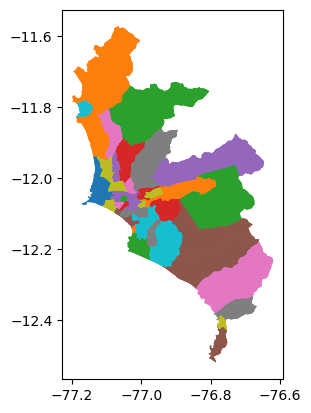

In [123]:
import matplotlib.pyplot as plt

ax = query_dataset.plot(column='location_query')
plt.show()

In [126]:
groupby_cols = ['location_query',  'geometry']

In [130]:
grouped_query_dataset = query_dataset.groupby(groupby_cols, as_index=False).agg({'id': lambda rows: [row for row in rows],
                                                                                 'geolocation': lambda rows: [row for row in rows]})

In [132]:
grouped_query_dataset = gpd.GeoDataFrame(grouped_query_dataset, geometry="geometry", crs="EPSG:4326")
grouped_query_dataset.head()

,location_query,geometry,id,geolocation
0,"CALLAO, BELLAVISTA","MULTIPOLYGON (((-77.08767 -12.05191, -77.08768...","[99b9c286-92a1-4fad-b656-e5b9cbb24817, 51f1d69...","[[-12.064253660434632, -77.12130089077424], [-..."
1,"CALLAO, CALLAO","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ...","[a7a539ea-6f4b-46ed-ab56-d398a190658c, 7074f88...","[[-12.040654106070631, -77.13630741549312], [-..."
2,"CALLAO, CARMEN DE LA LEGUA REYNOSO","MULTIPOLYGON (((-77.08303 -12.03634, -77.08297...","[f43a38a4-42e4-4de5-8cfb-df3ec89e900b, 5f757a4...","[[-12.045712844139185, -77.09439749593251], [-..."
3,"CALLAO, LA PERLA","MULTIPOLYGON (((-77.10465 -12.06328, -77.1046 ...","[274f2d67-f82b-409c-a410-4682256367d0, 8674647...","[[-12.068516141111967, -77.11166683431348], [-..."
4,"CALLAO, LA PUNTA","MULTIPOLYGON (((-77.15878 -12.06647, -77.15875...","[f027c7e2-39bb-46ee-b6ef-6e6b57959cc3, 6a0ce28...","[[-12.073358076377465, -77.16692584023498], [-..."


In [133]:
grouped_query_dataset.to_file('generated_data/grouped_properties.gpkg', driver='GPKG')

### Adding Query Object 

In [9]:
from app.models.PropertyLead import PropertySearchParams
from app.services.geolocation.location_verifier import verify_location

In [6]:
lead = PropertySearchParams(location={'value': 'CALLAO, BELLAVISTA'})
lead.test_query()
# Observaciones:
# status debe ser : 'test'
# geo_distance / geolocation no tiene lat lon

{'size': 3,
 'query': {'bool': {'must': [{'term': {'status': 'test'}}],
   'filter': [{'geo_distance': {'distance': '5km',
      'geolocation': {'lat': None, 'lon': None}}}],
   'should': [{'function_score': {'query': {'match_all': {}},
      'functions': [{'gauss': {'geolocation': {'origin': {'lat': None,
           'lon': None},
          'scale': '2km',
          'offset': '0km',
          'decay': 0.5}},
        'weight': 2.0}],
      'score_mode': 'sum'}}],
   'minimum_should_match': 1}}}

In [15]:
search_location = lead.location.value
_, coordinates = verify_location(search_location.lower())
lead.location.lat = coordinates.get("lat")
lead.location.lon = coordinates.get("lon")
_, coordinates

resultado obtenido con opencage


('Bellavista, Callao, Perú', {'lat': -12.0597362, 'lon': -77.1111612})

In [41]:
# Creamos una función para generar una celda con el query deseado
def generate_query_cell(location):
    lead = PropertySearchParams(location={'value': location})
    _, coordinates = verify_location(lead.location.value.lower())
    lead.location.lat = coordinates.get("lat")
    lead.location.lon = coordinates.get("lon")
    return lead.test_query()


In [42]:
grouped_query_dataset["lead"] = grouped_query_dataset.apply(lambda row: generate_query_cell(row['location_query']),axis=1)

resultado obtenido con opencage
resultado obtenido con opencage
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con opencage
resultado obtenido con opencage
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
re

In [43]:
grouped_query_dataset

,location_query,property_type,operation_type,location,status,id,lead
0,"CALLAO, BELLAVISTA",departamento,alquiler,Perú,test,"[99b9c286-92a1-4fad-b656-e5b9cbb24817, 51f1d69...","{'size': 3, 'query': {'bool': {'must': [{'term..."
1,"CALLAO, CALLAO",departamento,alquiler,Perú,test,"[a7a539ea-6f4b-46ed-ab56-d398a190658c, 7074f88...","{'size': 3, 'query': {'bool': {'must': [{'term..."
2,"CALLAO, CARMEN DE LA LEGUA REYNOSO",departamento,alquiler,Perú,test,"[f43a38a4-42e4-4de5-8cfb-df3ec89e900b, 5f757a4...","{'size': 3, 'query': {'bool': {'must': [{'term..."
3,"CALLAO, LA PERLA",departamento,alquiler,Perú,test,"[274f2d67-f82b-409c-a410-4682256367d0, 8674647...","{'size': 3, 'query': {'bool': {'must': [{'term..."
4,"CALLAO, LA PUNTA",departamento,alquiler,Perú,test,"[f027c7e2-39bb-46ee-b6ef-6e6b57959cc3, 6a0ce28...","{'size': 3, 'query': {'bool': {'must': [{'term..."
5,"CALLAO, MI PERU",departamento,alquiler,Perú,test,"[71a0df6c-7b27-47cd-94eb-63e90e8b2c9a, 2419d83...","{'size': 3, 'query': {'bool': {'must': [{'term..."
6,"CALLAO, VENTANILLA",departamento,alquiler,Perú,test,"[3216cff9-b37b-46c0-9195-e297529ad4ac, 008e94f...","{'size': 3, 'query': {'bool': {'must': [{'term..."
7,"LIMA, ANCON",departamento,alquiler,Perú,test,"[2af99227-44bb-45de-860f-4496c26e37b2, 7698964...","{'size': 3, 'query': {'bool': {'must': [{'term..."
8,"LIMA, ATE",departamento,alquiler,Perú,test,"[c52d8133-20a4-4269-be7e-f1b8b3311398, ab3ac09...","{'size': 3, 'query': {'bool': {'must': [{'term..."
9,"LIMA, BARRANCO",departamento,alquiler,Perú,test,"[611bca6e-7e05-43ad-8716-08fe7bb86d44, 4f85de6...","{'size': 3, 'query': {'bool': {'must': [{'term..."


In [45]:
grouped_query_dataset.to_csv('generated_data/grouped_query_dataset.csv', index=False)

## Searching

In [5]:
from app.services.embeddings.search_opensearch import search_similar_properties
import pandas as pd
import json
import ast

In [86]:
grouped_query_dataset = pd.read_csv('generated_data/grouped_query_dataset.csv')
grouped_query_dataset['lead'] = grouped_query_dataset['lead'].apply(ast.literal_eval)

In [87]:
grouped_query_dataset.head()

,location_query,property_type,operation_type,location,status,id,lead
0,"CALLAO, BELLAVISTA",departamento,alquiler,Perú,test,"['99b9c286-92a1-4fad-b656-e5b9cbb24817', '51f1...","{'size': 3, 'query': {'bool': {'must': [{'term..."
1,"CALLAO, CALLAO",departamento,alquiler,Perú,test,"['a7a539ea-6f4b-46ed-ab56-d398a190658c', '7074...","{'size': 3, 'query': {'bool': {'must': [{'term..."
2,"CALLAO, CARMEN DE LA LEGUA REYNOSO",departamento,alquiler,Perú,test,"['f43a38a4-42e4-4de5-8cfb-df3ec89e900b', '5f75...","{'size': 3, 'query': {'bool': {'must': [{'term..."
3,"CALLAO, LA PERLA",departamento,alquiler,Perú,test,"['274f2d67-f82b-409c-a410-4682256367d0', '8674...","{'size': 3, 'query': {'bool': {'must': [{'term..."
4,"CALLAO, LA PUNTA",departamento,alquiler,Perú,test,"['f027c7e2-39bb-46ee-b6ef-6e6b57959cc3', '6a0c...","{'size': 3, 'query': {'bool': {'must': [{'term..."


In [88]:
test_query = grouped_query_dataset['lead'][0]
type(test_query)

dict

In [89]:
result = search_similar_properties(test_query)
result
# De arranquev emos 3 errores.
#['99b9c286-92a1-4fad-b656-e5b9cbb24817', '51f1d69a-d15f-4d36-83c9-ea1a25ca2eff', 'b690ced9-2fa7-4f48-bf9e-8b9cf8f468e0']

[{'id': '274f2d67-f82b-409c-a410-4682256367d0',
  'description': '-  ',
  'property_type': 'departamento',
  'operation_type': 'alquiler',
  'address': '-',
  'price': 2661.0,
  'score': 2.1513765},
 {'id': '99b9c286-92a1-4fad-b656-e5b9cbb24817',
  'description': '-  ',
  'property_type': 'departamento',
  'operation_type': 'alquiler',
  'address': '-',
  'price': 2833.0,
  'score': 1.9130683},
 {'id': 'b690ced9-2fa7-4f48-bf9e-8b9cf8f468e0',
  'description': '-  ',
  'property_type': 'departamento',
  'operation_type': 'alquiler',
  'address': '-',
  'price': 1633.0,
  'score': 1.8864541}]

In [90]:
[hit['id'] for hit in result]

['274f2d67-f82b-409c-a410-4682256367d0',
 '99b9c286-92a1-4fad-b656-e5b9cbb24817',
 'b690ced9-2fa7-4f48-bf9e-8b9cf8f468e0']

In [ ]:
# Column function generator.
def generate_test_column(query):
    max_tries = 3
    for _ in range(max_tries):
        try:
            results = search_similar_properties(query)
            return [result['id'] for result in results]
        except Exception:
            continue
    return []    

In [95]:
grouped_query_dataset['test_result'] = grouped_query_dataset.apply(lambda row: generate_test_column(row['lead']),axis=1)

In [96]:
grouped_query_dataset

,location_query,property_type,operation_type,location,status,id,lead,test_result
0,"CALLAO, BELLAVISTA",departamento,alquiler,Perú,test,"['99b9c286-92a1-4fad-b656-e5b9cbb24817', '51f1...","{'size': 3, 'query': {'bool': {'must': [{'term...","[274f2d67-f82b-409c-a410-4682256367d0, 99b9c28..."
1,"CALLAO, CALLAO",departamento,alquiler,Perú,test,"['a7a539ea-6f4b-46ed-ab56-d398a190658c', '7074...","{'size': 3, 'query': {'bool': {'must': [{'term...","[7074f888-0267-443b-a277-e975e931a685, a7a539e..."
2,"CALLAO, CARMEN DE LA LEGUA REYNOSO",departamento,alquiler,Perú,test,"['f43a38a4-42e4-4de5-8cfb-df3ec89e900b', '5f75...","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813..."
3,"CALLAO, LA PERLA",departamento,alquiler,Perú,test,"['274f2d67-f82b-409c-a410-4682256367d0', '8674...","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813..."
4,"CALLAO, LA PUNTA",departamento,alquiler,Perú,test,"['f027c7e2-39bb-46ee-b6ef-6e6b57959cc3', '6a0c...","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813..."
5,"CALLAO, MI PERU",departamento,alquiler,Perú,test,"['71a0df6c-7b27-47cd-94eb-63e90e8b2c9a', '2419...","{'size': 3, 'query': {'bool': {'must': [{'term...","[8568a146-23c2-4275-8661-230bbcdde6a2, 71a0df6..."
6,"CALLAO, VENTANILLA",departamento,alquiler,Perú,test,"['3216cff9-b37b-46c0-9195-e297529ad4ac', '008e...","{'size': 3, 'query': {'bool': {'must': [{'term...","[008e94fc-0151-4a13-b451-cb0ea393b8f4, 2419d83..."
7,"LIMA, ANCON",departamento,alquiler,Perú,test,"['2af99227-44bb-45de-860f-4496c26e37b2', '7698...","{'size': 3, 'query': {'bool': {'must': [{'term...","[390497a6-8892-43fa-bfa4-1a625d728260, 2af9922..."
8,"LIMA, ATE",departamento,alquiler,Perú,test,"['c52d8133-20a4-4269-be7e-f1b8b3311398', 'ab3a...","{'size': 3, 'query': {'bool': {'must': [{'term...","[c52d8133-20a4-4269-be7e-f1b8b3311398, 9d6153b..."
9,"LIMA, BARRANCO",departamento,alquiler,Perú,test,"['611bca6e-7e05-43ad-8716-08fe7bb86d44', '4f85...","{'size': 3, 'query': {'bool': {'must': [{'term...","[0bc713be-28ca-4217-84a4-0540260376bf, 611bca6..."


In [97]:
def score_generator(objective:list, predicted:list):
    score = 0
    for id in predicted:
        if id in objective:
            score += 1
    return score


In [98]:
grouped_query_dataset['score'] = grouped_query_dataset.apply(lambda row: score_generator(row['id'], row['test_result']), axis=1)

In [99]:
grouped_query_dataset

,location_query,property_type,operation_type,location,status,id,lead,test_result,score
0,"CALLAO, BELLAVISTA",departamento,alquiler,Perú,test,"['99b9c286-92a1-4fad-b656-e5b9cbb24817', '51f1...","{'size': 3, 'query': {'bool': {'must': [{'term...","[274f2d67-f82b-409c-a410-4682256367d0, 99b9c28...",2
1,"CALLAO, CALLAO",departamento,alquiler,Perú,test,"['a7a539ea-6f4b-46ed-ab56-d398a190658c', '7074...","{'size': 3, 'query': {'bool': {'must': [{'term...","[7074f888-0267-443b-a277-e975e931a685, a7a539e...",2
2,"CALLAO, CARMEN DE LA LEGUA REYNOSO",departamento,alquiler,Perú,test,"['f43a38a4-42e4-4de5-8cfb-df3ec89e900b', '5f75...","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813...",0
3,"CALLAO, LA PERLA",departamento,alquiler,Perú,test,"['274f2d67-f82b-409c-a410-4682256367d0', '8674...","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813...",0
4,"CALLAO, LA PUNTA",departamento,alquiler,Perú,test,"['f027c7e2-39bb-46ee-b6ef-6e6b57959cc3', '6a0c...","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813...",0
5,"CALLAO, MI PERU",departamento,alquiler,Perú,test,"['71a0df6c-7b27-47cd-94eb-63e90e8b2c9a', '2419...","{'size': 3, 'query': {'bool': {'must': [{'term...","[8568a146-23c2-4275-8661-230bbcdde6a2, 71a0df6...",2
6,"CALLAO, VENTANILLA",departamento,alquiler,Perú,test,"['3216cff9-b37b-46c0-9195-e297529ad4ac', '008e...","{'size': 3, 'query': {'bool': {'must': [{'term...","[008e94fc-0151-4a13-b451-cb0ea393b8f4, 2419d83...",2
7,"LIMA, ANCON",departamento,alquiler,Perú,test,"['2af99227-44bb-45de-860f-4496c26e37b2', '7698...","{'size': 3, 'query': {'bool': {'must': [{'term...","[390497a6-8892-43fa-bfa4-1a625d728260, 2af9922...",1
8,"LIMA, ATE",departamento,alquiler,Perú,test,"['c52d8133-20a4-4269-be7e-f1b8b3311398', 'ab3a...","{'size': 3, 'query': {'bool': {'must': [{'term...","[c52d8133-20a4-4269-be7e-f1b8b3311398, 9d6153b...",1
9,"LIMA, BARRANCO",departamento,alquiler,Perú,test,"['611bca6e-7e05-43ad-8716-08fe7bb86d44', '4f85...","{'size': 3, 'query': {'bool': {'must': [{'term...","[0bc713be-28ca-4217-84a4-0540260376bf, 611bca6...",3


In [102]:
general_score = grouped_query_dataset['score'].sum() / (len(grouped_query_dataset)*3)
general_score

0.31333333333333335

In [ ]:
grouped_query_dataset['score'].mean()
# 

0.94

The scores are really bad for some places. 

Theories: 
- Bad Coordinates: Most of coordinates were parsed using fuzzy wuzzy, remaining were parsed using nominatim. There might be an issue with fuzzy wuzzy. -> Create tests for each of them and evaluate.
- Bad Search Algorithm

# Creating a Generic Function

In [3]:
# Dataset de prueba
input_dataset = gpd.read_file('generated_data/grouped_properties.gpkg')
input_dataset.head()

,location_query,id,geolocation,geometry
0,"CALLAO, BELLAVISTA","['99b9c286-92a1-4fad-b656-e5b9cbb24817', '51f1...","['[-12.064253660434632, -77.12130089077424]', ...","MULTIPOLYGON (((-77.08767 -12.05191, -77.08768..."
1,"CALLAO, CALLAO","['a7a539ea-6f4b-46ed-ab56-d398a190658c', '7074...","['[-12.040654106070631, -77.13630741549312]', ...","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ..."
2,"CALLAO, CARMEN DE LA LEGUA REYNOSO","['f43a38a4-42e4-4de5-8cfb-df3ec89e900b', '5f75...","['[-12.045712844139185, -77.09439749593251]', ...","MULTIPOLYGON (((-77.08303 -12.03634, -77.08297..."
3,"CALLAO, LA PERLA","['274f2d67-f82b-409c-a410-4682256367d0', '8674...","['[-12.068516141111967, -77.11166683431348]', ...","MULTIPOLYGON (((-77.10465 -12.06328, -77.1046 ..."
4,"CALLAO, LA PUNTA","['f027c7e2-39bb-46ee-b6ef-6e6b57959cc3', '6a0c...","['[-12.073358076377465, -77.16692584023498]', ...","MULTIPOLYGON (((-77.15878 -12.06647, -77.15875..."


In [ ]:
# methods: fuzz / forward_search
from app.services.geolocation.methods.rapidfuzz_checker import check_fuzz
from app.services.geolocation.methods.opencage_service import forward_search

In [183]:
def check_fuzz_2(input_str:str):
    location, _, coordinates = check_fuzz(input_str.lower())
    return location, coordinates

In [144]:
test_str = input_dataset.iloc[0,0].lower()
print(check_fuzz_2(test_str))
print(forward_search(test_str))



('la victoria', {'lat': -12.0741, 'lon': -77.0122})
('Bellavista, Callao, Perú', {'lat': -12.0597362, 'lon': -77.1111612})


In [142]:
##### Test #####
def test_query(latitude, longitude, max_distance: int = 5):

    # bloques must
    must = []

    must.append({"term": {"status": "test"}})

    # bloques filter
    filter = []
    # if self.price.value.max:
    #     filter.append({"range": {"price": {"lte" : self.price.value.max}}})

    # geolocalización. Filtro.
    filter.append(
        {
            "geo_distance": {
                "distance": f"{max_distance}km",
                "geolocation": {
                    "lat": latitude,
                    "lon": longitude,
                },
            }
        }
    )

    # bloques should
    should = []

    functions = []
    # Funcion de decaimiento por geolocalizacion.
    functions.append(
        {
            "gauss": {
                "geolocation": {
                    "origin": {
                        "lat": latitude,
                        "lon": longitude,
                    },
                    "scale": "2km",  # Distancia donde el score empieza a decaer
                    "offset": "0km",  # Distancia sin penalización
                    "decay": 0.5,  # Factor de decaimiento
                }
            },
            "weight": 2.0,  # Peso alto para priorizar cercanía
        }
    )
    
    if functions:
        should.append(
            {
                "function_score": {
                    "query": {"match_all": {}},
                    "functions": functions,
                    "score_mode": "sum",
                }
            }
        )

    # query construction
    bool = dict()
    if must:
        bool["must"] = must
    if filter:
        bool["filter"] = filter
    if should:
        bool["should"] = should

    query = {
        "size": 3,
        "query": {"bool": {**bool, "minimum_should_match": 1}},
    }

    return query

In [66]:
# Column function generator.
def generate_test_column(query):
    max_tries = 3
    for _ in range(max_tries):
        try:
            results = search_similar_properties(query)
            return [result['id'] for result in results]
        except Exception:
            continue
    return [] 

def score_generator(objective:list, predicted:list):
    score = 0
    for id in predicted:
        if id in objective:
            score += 1
    return score

In [ ]:
def search_tester(input_dataset: gpd.GeoDataFrame, geo_function, query_function):
    list_example: list = input_dataset[0]
    output_df = input_dataset.copy()
    new_cols = output_df.apply(lambda row: pd.Series(geo_function(row["location_query"])), axis=1)
    output_df['geo_location'] = new_cols[0]
    output_df['geo_coordinates'] = new_cols[1].apply(lambda x: list(x.values()))
    output_df['query_format'] = output_df.apply(lambda row: query_function(row['geo_coordinates'][0], row['geo_coordinates'][1]), axis=1)
    output_df['search_result'] = output_df.apply(lambda row: generate_test_column(row['query_format']), axis=1)
    output_df['score'] = output_df.apply(lambda row: score_generator(row['id'], row['search_result']),axis=1)
    
    return output_df


In [71]:
def scorer(input_dataset):
    general_score = input_dataset['score'].sum() / (len(input_dataset)*3)
    mean_score = input_dataset['score'].mean()
    return general_score, mean_score

## Fuzzy Wuzzy testing

In [ ]:
result_df = search_tester(input_dataset, check_fuzz_2, test_query)

In [187]:
result_df.head()

,location_query,id,geolocation,geometry,geo_location,geo_coordinates,query_format,search_result,score
0,"CALLAO, BELLAVISTA","['99b9c286-92a1-4fad-b656-e5b9cbb24817', '51f1...","['[-12.064253660434632, -77.12130089077424]', ...","MULTIPOLYGON (((-77.08767 -12.05191, -77.08768...",la victoria,"[-12.0741, -77.0122]","{'size': 3, 'query': {'bool': {'must': [{'term...","[ea6e2224-f523-4f57-b729-fd7f594345af, e2212dc...",0
1,"CALLAO, CALLAO","['a7a539ea-6f4b-46ed-ab56-d398a190658c', '7074...","['[-12.040654106070631, -77.13630741549312]', ...","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ...",carabayllo,"[-11.8902, -77.0415]","{'size': 3, 'query': {'bool': {'must': [{'term...","[5ad6905d-a14e-494f-9370-971129d553d9, 3c02470...",0
2,"CALLAO, CARMEN DE LA LEGUA REYNOSO","['f43a38a4-42e4-4de5-8cfb-df3ec89e900b', '5f75...","['[-12.045712844139185, -77.09439749593251]', ...","MULTIPOLYGON (((-77.08303 -12.03634, -77.08297...",la molina,"[-12.0895, -76.9397]","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813...",0
3,"CALLAO, LA PERLA","['274f2d67-f82b-409c-a410-4682256367d0', '8674...","['[-12.068516141111967, -77.11166683431348]', ...","MULTIPOLYGON (((-77.10465 -12.06328, -77.1046 ...",la molina,"[-12.0895, -76.9397]","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813...",0
4,"CALLAO, LA PUNTA","['f027c7e2-39bb-46ee-b6ef-6e6b57959cc3', '6a0c...","['[-12.073358076377465, -77.16692584023498]', ...","MULTIPOLYGON (((-77.15878 -12.06647, -77.15875...",la molina,"[-12.0895, -76.9397]","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813...",0


In [189]:
scorer(result_df)

(0.26, 0.78)

Conclusion:
- Bad Results, Fast

## Opencage Testing

In [190]:
result_df = search_tester(input_dataset, forward_search, test_query)

In [70]:
scorer(result_df)

NameError: name 'scorer' is not defined

Conclusion:
- Average Results, Slower: 1minute

In [195]:
from matplotlib.colors import ListedColormap

score_cmap = ListedColormap(["#b30000", "#fc8d59", "#fee08b", "#ffffbf"])  # 0→red

<Axes: >

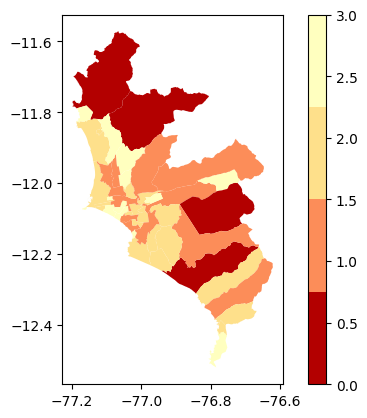

In [196]:
result_df.plot(column="score", cmap=score_cmap, vmin=0, vmax=3, legend=True)

# New Implementation: Geometry Search

In [77]:
from shapely.geometry import MultiPolygon, Polygon

def simplify_for_geo_polygon(geom: Polygon | MultiPolygon, tolerance: float = 0.0005):
    # Reduce points , and formats the output for geo shape queries
    polygon = max(geom.geoms, key=lambda g: g.area) if isinstance(geom, MultiPolygon) else geom
    simplified = polygon.simplify(tolerance, preserve_topology=True)
    coords = list(simplified.exterior.coords)
    if coords[0] != coords[-1]:
        coords.append(coords[0])
    return [{"lat": lat, "lon": lon} for lon, lat in coords[:100]]

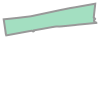

In [31]:
raw_shape = input_dataset.loc[0]['geometry']
raw_shape

In [35]:
simplified_shape = simplify_for_geo_polygon(raw_shape)
simplified_shape

[{'lat': -12.051911846999928, 'lon': -77.08767263099998},
 {'lat': -12.058686147999936, 'lon': -77.08842368199998},
 {'lat': -12.059395965999954, 'lon': -77.08779398399997},
 {'lat': -12.06079994099997, 'lon': -77.08818119899996},
 {'lat': -12.061518569999976, 'lon': -77.08710888899998},
 {'lat': -12.063435959999936, 'lon': -77.10834402699999},
 {'lat': -12.065831182999943, 'lon': -77.11914754899993},
 {'lat': -12.067646705999948, 'lon': -77.13307308999998},
 {'lat': -12.059694996999951, 'lon': -77.13427217799995},
 {'lat': -12.058197657999926, 'lon': -77.12079985499997},
 {'lat': -12.051911846999928, 'lon': -77.08767263099998}]

In [38]:
x = [shape['lat'] for shape in simplified_shape]
y = [shape['lon'] for shape in simplified_shape]

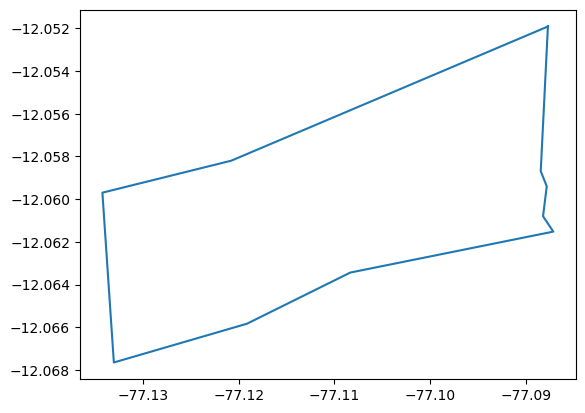

In [42]:
import matplotlib.pyplot as plt
# Verifiying consistency.
plt.plot(y, x)

In [45]:
def make_geo_query(points):
    geo_polygon_query = {
        "query": {
            "bool": {
                "filter": {
                    "geo_polygon": {
                        "geolocation": {"points": points}
                    }
                }
            }
        }
    }
    return geo_polygon_query

In [46]:
results = search_similar_properties(make_geo_query(simplified_shape))
results

[{'id': 'b690ced9-2fa7-4f48-bf9e-8b9cf8f468e0',
  'description': '-  ',
  'property_type': 'departamento',
  'operation_type': 'alquiler',
  'address': '-',
  'price': 1633.0,
  'score': 0.0},
 {'id': '5f762eb6-327b-4913-b2dd-f0c4160ad71a',
  'description': 'Linda casa en Bellavista callao.\n3 dormitorios\n2 baños\n1 medio baño\nSala y comedor\nPatio amplio\nCochera para 1 auto  ',
  'property_type': 'casa',
  'operation_type': 'arriendo',
  'address': 'Perú, Lima',
  'price': 260000.0,
  'score': 0.0},
 {'id': '1af0418b-1e14-41c2-be64-a5d1bc668c54',
  'description': 'Linda casa en Bellavista callao.\n3 dormitorios\n2 baños\n1 medio baño\nSala y comedor\nPatio amplio\nCochera para 1 auto  ',
  'property_type': 'casa',
  'operation_type': 'venta',
  'address': 'Luis Godin 4760',
  'price': 260000.0,
  'score': 0.0},
 {'id': '99b9c286-92a1-4fad-b656-e5b9cbb24817',
  'description': '-  ',
  'property_type': 'departamento',
  'operation_type': 'alquiler',
  'address': '-',
  'price': 2833.

In [49]:
##### Test #####
def test_shape_query(points):

    # bloques must
    must = []

    must.append({"term": {"status": "test"}})

    # bloques filter
    filter = []

    # geolocalización. Filtro.
    filter.append(
        {
            "geo_polygon": {
                "geolocation": {"points": points}
            }
        }
    )

    # query construction
    bool = dict()
    if must:
        bool["must"] = must
    if filter:
        bool["filter"] = filter

    query = {
        "size": 3,
        "query": {"bool": {**bool}},
    }

    return query

In [50]:
results = search_similar_properties(test_shape_query(simplified_shape))
results


[{'id': 'b690ced9-2fa7-4f48-bf9e-8b9cf8f468e0',
  'description': '-  ',
  'property_type': 'departamento',
  'operation_type': 'alquiler',
  'address': '-',
  'price': 1633.0,
  'score': 0.45675838},
 {'id': '99b9c286-92a1-4fad-b656-e5b9cbb24817',
  'description': '-  ',
  'property_type': 'departamento',
  'operation_type': 'alquiler',
  'address': '-',
  'price': 2833.0,
  'score': 0.36229295},
 {'id': '51f1d69a-d15f-4d36-83c9-ea1a25ca2eff',
  'description': '-  ',
  'property_type': 'departamento',
  'operation_type': 'alquiler',
  'address': '-',
  'price': 1133.0,
  'score': 0.36229295}]

In [63]:
[result['id'] for result in results]

['b690ced9-2fa7-4f48-bf9e-8b9cf8f468e0',
 '99b9c286-92a1-4fad-b656-e5b9cbb24817',
 '51f1d69a-d15f-4d36-83c9-ea1a25ca2eff']

In [55]:
# We must simplify the shapes.
input_dataset["simplified_geometry"] = input_dataset.apply(lambda row: simplify_for_geo_polygon(row['geometry']), axis=1)
input_dataset.head()

,location_query,id,geolocation,geometry,simplified_geometry
0,"CALLAO, BELLAVISTA","['99b9c286-92a1-4fad-b656-e5b9cbb24817', '51f1...","['[-12.064253660434632, -77.12130089077424]', ...","MULTIPOLYGON (((-77.08767 -12.05191, -77.08768...","[{'lat': -12.051911846999928, 'lon': -77.08767..."
1,"CALLAO, CALLAO","['a7a539ea-6f4b-46ed-ab56-d398a190658c', '7074...","['[-12.040654106070631, -77.13630741549312]', ...","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ...","[{'lat': -11.936819645999947, 'lon': -77.12994..."
2,"CALLAO, CARMEN DE LA LEGUA REYNOSO","['f43a38a4-42e4-4de5-8cfb-df3ec89e900b', '5f75...","['[-12.045712844139185, -77.09439749593251]', ...","MULTIPOLYGON (((-77.08303 -12.03634, -77.08297...","[{'lat': -12.036344483999926, 'lon': -77.08302..."
3,"CALLAO, LA PERLA","['274f2d67-f82b-409c-a410-4682256367d0', '8674...","['[-12.068516141111967, -77.11166683431348]', ...","MULTIPOLYGON (((-77.10465 -12.06328, -77.1046 ...","[{'lat': -12.063281721999942, 'lon': -77.10465..."
4,"CALLAO, LA PUNTA","['f027c7e2-39bb-46ee-b6ef-6e6b57959cc3', '6a0c...","['[-12.073358076377465, -77.16692584023498]', ...","MULTIPOLYGON (((-77.15878 -12.06647, -77.15875...","[{'lat': -12.066473196999937, 'lon': -77.15878..."


In [56]:
input_dataset.to_file('generated_data/grouped_properties_simplified.gpkg', driver='GPKG')

In [67]:
def search_tester_shape(input_dataset: gpd.GeoDataFrame):
    output_df = input_dataset.copy()
    result_list = []
    for i in range(len(input_dataset)):
        shape = input_dataset.loc[i]['simplified_geometry']
        query = test_shape_query(shape)
        raw_result = search_similar_properties(query)
        properties_result = [result['id'] for result in raw_result]
        result_list.append(properties_result)
    output_df['search_result'] = result_list
    output_df['score'] = output_df.apply(lambda row: score_generator(row['id'], row['search_result']),axis=1)
    
    return output_df

In [68]:
shape_results = search_tester_shape(input_dataset)

In [72]:
scorer(shape_results)

(0.9933333333333333, 2.98)

In [75]:
shape_results[shape_results['score']<3].loc[11]

location_query                                          LIMA, CARABAYLLO
id                     ['5ad6905d-a14e-494f-9370-971129d553d9', '46a5...
geolocation            ['[-11.869664206239042, -77.01381585159824]', ...
geometry               MULTIPOLYGON (((-76.90214857999996 -11.7288722...
simplified_geometry    [{'lat': -11.72887226499995, 'lon': -76.902148...
search_result          [46a50e3d-6f13-48aa-829c-c46f7ca6b641, 5ad6905...
score                                                                  2
Name: 11, dtype: object

In [ ]:
['46a50e3d-6f13-48aa-829c-c46f7ca6b641', '5ad6905d-a14e-494f-9370-971129d553d9']
['5ad6905d-a14e-494f-9370-971129d553d9', '46a50e3d-6f13-48aa-829c-c46f7ca6b641', '4873d3e1-0531-4f04-926d-dd87c69964a0']

# Step 2: Knowledge Base Search Database

The main goal is to create a database that we can query with the location user is asking for and return a geoshape to perform look ups with. This database will possibly later be scaled into a hierarchical database for location. 

# Step 3: Insert Data

Debemos cargar los datos a nuestra base de datos en aurora, para tal caso considerar:
- Jerarquia de localizaciones: Country, City, District, etc
- Convertir los poligonos en listas resumidas y luego subirlas en el formato de la base de datos.

In [78]:
import geopandas as gpd

In [ ]:
# Dataset
input_dataset = gpd.read_file('generated_data/grouped_properties.gpkg')
input_dataset['CIUDAD'] = input_dataset['location_query'].apply(lambda x: x.split(', ')[0])
input_dataset['DISTRITO'] = input_dataset['location_query'].apply(lambda x: x.split(', ')[1])
input_dataset.head()    

,location_query,id,geolocation,geometry,CIUDAD,DISTRITO
0,"CALLAO, BELLAVISTA","['99b9c286-92a1-4fad-b656-e5b9cbb24817', '51f1...","['[-12.064253660434632, -77.12130089077424]', ...","MULTIPOLYGON (((-77.08767 -12.05191, -77.08768...",CALLAO,BELLAVISTA
1,"CALLAO, CALLAO","['a7a539ea-6f4b-46ed-ab56-d398a190658c', '7074...","['[-12.040654106070631, -77.13630741549312]', ...","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ...",CALLAO,CALLAO
2,"CALLAO, CARMEN DE LA LEGUA REYNOSO","['f43a38a4-42e4-4de5-8cfb-df3ec89e900b', '5f75...","['[-12.045712844139185, -77.09439749593251]', ...","MULTIPOLYGON (((-77.08303 -12.03634, -77.08297...",CALLAO,CARMEN DE LA LEGUA REYNOSO
3,"CALLAO, LA PERLA","['274f2d67-f82b-409c-a410-4682256367d0', '8674...","['[-12.068516141111967, -77.11166683431348]', ...","MULTIPOLYGON (((-77.10465 -12.06328, -77.1046 ...",CALLAO,LA PERLA
4,"CALLAO, LA PUNTA","['f027c7e2-39bb-46ee-b6ef-6e6b57959cc3', '6a0c...","['[-12.073358076377465, -77.16692584023498]', ...","MULTIPOLYGON (((-77.15878 -12.06647, -77.15875...",CALLAO,LA PUNTA


In [90]:
'CALLAO, BELLAVISTA'.split(', ')[0]

'CALLAO'

In [93]:
# funciones necesarias 
from shapely.geometry import MultiPolygon, Polygon

def simplify_for_geo_polygon(geom: Polygon | MultiPolygon, tolerance: float = 0.0005):
    # Reduce points , and formats the output for geo shape queries
    polygon = max(geom.geoms, key=lambda g: g.area) if isinstance(geom, MultiPolygon) else geom
    simplified = polygon.simplify(tolerance, preserve_topology=True)
    coords = list(simplified.exterior.coords)
    if coords[0] != coords[-1]:
        coords.append(coords[0])
    return [{"lat": lat, "lon": lon} for lon, lat in coords[:100]]

In [87]:
import psycopg2
from psycopg2.extras import execute_values
from app.core.config import AURORA_DB_URL, AURORA_DB_USER, AURORA_DB_PASSWORD

In [82]:
DB_CONFIG = {
    'host': AURORA_DB_URL,
    'port': 5432,
    'database': 'locations',
    'user': AURORA_DB_USER,
    'password': AURORA_DB_PASSWORD
}

In [83]:
# Funciones de utilidad
def get_db_connection():
    """Crear conexión a PostgreSQL"""
    return psycopg2.connect(**DB_CONFIG)

def geometry_to_wkt(geometry):
    """
    Convertir geometría de Shapely a WKT para PostGIS
    Simplifica la geometría si tiene más de 100 puntos
    """
    if geometry is None:
        return None
    
    # Simplificar geometría si es muy compleja
    if hasattr(geometry, 'exterior'):
        num_points = len(geometry.exterior.coords)
        if num_points > 100:
            # Simplificar a ~100 puntos (tolerancia en grados, ~11 metros)
            geometry = geometry.simplify(0.0001, preserve_topology=True)
    
    return geometry.wkt

def geometry_to_centroid_wkt(geometry):
    """Obtener el centroid de una geometría como WKT"""
    if geometry is None:
        return None
    return geometry.centroid.wkt

def normalize_name(name):
    """Normalizar nombre (lowercase, sin acentos, trim)"""
    import unicodedata
    if not name:
        return ''
    # Remover acentos
    nfkd = unicodedata.normalize('NFKD', name)
    name_no_accents = ''.join([c for c in nfkd if not unicodedata.combining(c)])
    return name_no_accents.lower().strip()

In [84]:
# Función para inserción de país Perú
def insert_country_peru(cursor):
    """
    Insertar el país Perú
    Returns: ID del país insertado
    """
    print("Insertando país: Perú...")
    
    country_data = {
        'type': 'country',
        'country_code': 'PE',
        'name': 'Perú',
        'centroid_wkt': 'POINT(-75.0152 -9.1900)'  # Centro aproximado de Perú
    }
    
    query = """
        INSERT INTO locations (type, country_code, name, name_norm, centroid)
        VALUES (%(type)s, %(country_code)s, %(name)s, %(name_norm)s, ST_SetSRID(ST_GeomFromText(%(centroid_wkt)s), 4326))
        ON CONFLICT DO NOTHING
        RETURNING id;
    """
    
    country_data['name_norm'] = normalize_name(country_data['name'])
    
    cursor.execute(query, country_data)
    result = cursor.fetchone()
    
    if result:
        country_id = result[0]
        print(f"✓ País insertado con ID: {country_id}")
        return country_id
    else:
        # Ya existe, obtener el ID
        cursor.execute(
            "SELECT id FROM locations WHERE type = 'country' AND country_code = 'PE'"
        )
        country_id = cursor.fetchone()[0]
        print(f"✓ País ya existente con ID: {country_id}")
        return country_id

In [85]:
# Insertar ciudades de Lima y Callao
def insert_cities(cursor, country_id):
    """
    Insertar las ciudades de Lima y Callao
    Returns: Dict con IDs de las ciudades {'Lima': id, 'Callao': id}
    """
    print("\nInsertando ciudades: Lima y Callao...")
    
    cities = [
        {
            'name': 'Lima',
            'type': 'city',
            'country_code': 'PE',
            'parent_id': country_id,
            'centroid_wkt': 'POINT(-77.0428 -12.0464)'  # Centro de Lima
        },
        {
            'name': 'Callao',
            'type': 'city',
            'country_code': 'PE',
            'parent_id': country_id,
            'centroid_wkt': 'POINT(-77.1197 -12.0566)'  # Centro de Callao
        }
    ]
    
    city_ids = {}
    
    query = """
        INSERT INTO locations (type, country_code, parent_id, name, name_norm, centroid)
        VALUES (%(type)s, %(country_code)s, %(parent_id)s, %(name)s, %(name_norm)s, 
                ST_SetSRID(ST_GeomFromText(%(centroid_wkt)s), 4326))
        ON CONFLICT DO NOTHING
        RETURNING id, name;
    """
    
    for city in cities:
        city['name_norm'] = normalize_name(city['name'])
        cursor.execute(query, city)
        result = cursor.fetchone()
        
        if result:
            city_id, city_name = result
            city_ids[city_name] = city_id
            print(f"✓ Ciudad '{city_name}' insertada con ID: {city_id}")
        else:
            # Ya existe, obtener el ID
            cursor.execute(
                "SELECT id FROM locations WHERE type = 'city' AND name = %s AND country_code = 'PE'",
                (city['name'],)
            )
            result = cursor.fetchone()
            if result:
                city_ids[city['name']] = result[0]
                print(f"✓ Ciudad '{city['name']}' ya existente con ID: {result[0]}")
    
    return city_ids

In [88]:
# Funcion para insertar ciudades
def load_districts_from_geodataframe(gdf, city_ids, cursor):
    """
    Cargar distritos desde un GeoDataFrame
    
    Args:
        gdf: GeoDataFrame con columnas:
             - 'nombre' o 'name' o 'DISTRITO': nombre del distrito
             - 'ciudad' o 'CIUDAD': 'Lima' o 'Callao'
             - 'geometry': geometría del distrito
        city_ids: Dict con IDs de las ciudades {'Lima': id, 'Callao': id}
        cursor: Cursor de PostgreSQL
    """
    print(f"\nCargando {len(gdf)} distritos desde GeoDataFrame...")
    
    # Detectar columnas (ajustar según tu GeoDataFrame)
    name_col = None
    city_col = None
    
    # Buscar columna de nombre
    for col in ['nombre', 'name', 'NOMBRE', 'DISTRITO', 'distrito']:
        if col in gdf.columns:
            name_col = col
            break
    
    # Buscar columna de ciudad
    for col in ['ciudad', 'CIUDAD', 'city', 'provincia']:
        if col in gdf.columns:
            city_col = col
            break
    
    if not name_col:
        raise ValueError("No se encontró columna de nombre del distrito. "
                        "Columnas disponibles: " + str(gdf.columns.tolist()))
    
    print(f"Usando columna de nombre: '{name_col}'")
    if city_col:
        print(f"Usando columna de ciudad: '{city_col}'")
    
    # Asegurar que estamos en WGS84 (EPSG:4326)
    if gdf.crs and gdf.crs.to_epsg() != 4326:
        print(f"Reproyectando de {gdf.crs} a EPSG:4326...")
        gdf = gdf.to_crs(epsg=4326)
    
    query = """
        INSERT INTO locations (
            type, country_code, parent_id, name, name_norm, 
            centroid, geom
        )
        VALUES %s
        ON CONFLICT DO NOTHING
        RETURNING id, name;
    """
    
    # Preparar datos
    districts_data = []
    
    for idx, row in gdf.iterrows():
        district_name = row[name_col]
        
        # Determinar ciudad padre
        if city_col and row[city_col]:
            city_name = row[city_col]
            # Normalizar nombre de ciudad
            if 'callao' in city_name.lower():
                parent_id = city_ids.get('Callao')
            else:
                parent_id = city_ids.get('Lima')
        else:
            # Por defecto, asumir Lima
            parent_id = city_ids.get('Lima')
        
        if not parent_id:
            print(f"⚠ Advertencia: No se pudo determinar ciudad para '{district_name}', usando Lima")
            parent_id = city_ids.get('Lima')
        
        geometry = row['geometry']
        
        # Convertir geometrías
        centroid_wkt = geometry_to_centroid_wkt(geometry)
        geom_wkt = geometry_to_wkt(geometry)
        
        districts_data.append((
            'district',                      # type
            'PE',                            # country_code
            parent_id,                       # parent_id
            district_name,                   # name
            normalize_name(district_name),   # name_norm
            f"SRID=4326;{centroid_wkt}" if centroid_wkt else None,
            f"SRID=4326;{geom_wkt}" if geom_wkt else None
        ))
    
    # Insertar en batch
    execute_values(
        cursor,
        query,
        districts_data,
        template="""(
            %s, %s, %s, %s, %s,
            ST_GeomFromEWKT(%s),
            ST_GeomFromEWKT(%s)
        )"""
    )
    
    print(f"✓ {len(districts_data)} distritos insertados/actualizados")

In [94]:
def main():
    """
    Función principal para cargar datos de Perú
    """
    print("="*70)
    print("CARGA DE DATOS DE LOCATIONS - PERÚ (LIMA Y CALLAO)")
    print("="*70)
    
    # Conectar a la base de datos
    conn = get_db_connection()
    cursor = conn.cursor()
    
    try:
        # PASO 1: Insertar país
        country_id = insert_country_peru(cursor)
        conn.commit()
        
        # PASO 2: Insertar ciudades
        city_ids = insert_cities(cursor, country_id)
        conn.commit()
        
        # PASO 3: Cargar distritos desde GeoDataFrame
        # ⚠️ AJUSTA ESTA PARTE SEGÚN TU ARCHIVO
        
        # Opción A: Cargar desde archivo shapefile
        # print("\nCargando distritos desde archivo...")
        # gdf = gpd.read_file('ruta/a/tu/archivo.shp')
        
        # Opción B: Cargar desde GeoJSON
        # gdf = gpd.read_file('ruta/a/tu/archivo.geojson')
        
        # Opción C: Cargar desde GeoPackage
        # gdf = gpd.read_file('ruta/a/tu/archivo.gpkg')
        
        # Opción D: Si ya tienes un GeoDataFrame en memoria
        gdf = input_dataset
        
        # Inspeccionar columnas disponibles
        print(f"\nColumnas disponibles en GeoDataFrame: {gdf.columns.tolist()}")
        print(f"CRS actual: {gdf.crs}")
        print(f"\nPrimeras filas:")
        print(gdf.head())
        
        # Cargar distritos
        load_districts_from_geodataframe(gdf, city_ids, cursor)
        conn.commit()
        
        print("\n" + "="*70)
        print("✓ CARGA COMPLETADA EXITOSAMENTE")
        print("="*70)
        
        # Mostrar estadísticas
        cursor.execute("""
            SELECT type, COUNT(*) as total
            FROM locations
            WHERE country_code = 'PE'
            GROUP BY type
            ORDER BY 
                CASE type
                    WHEN 'country' THEN 1
                    WHEN 'city' THEN 2
                    WHEN 'district' THEN 3
                    ELSE 4
                END;
        """)
        
        print("\nEstadísticas de carga:")
        for row in cursor.fetchall():
            print(f"  - {row[0]}: {row[1]} registros")
        
    except Exception as e:
        print(f"\n❌ Error durante la carga: {e}")
        conn.rollback()
        raise
    
    finally:
        cursor.close()
        conn.close()

In [96]:
main()

CARGA DE DATOS DE LOCATIONS - PERÚ (LIMA Y CALLAO)
Insertando país: Perú...
✓ País insertado con ID: 2

Insertando ciudades: Lima y Callao...
✓ Ciudad 'Lima' insertada con ID: 3
✓ Ciudad 'Callao' insertada con ID: 4

Columnas disponibles en GeoDataFrame: ['location_query', 'id', 'geolocation', 'geometry', 'CIUDAD', 'DISTRITO']
CRS actual: EPSG:4326

Primeras filas:
                       location_query  \
0                  CALLAO, BELLAVISTA   
1                      CALLAO, CALLAO   
2  CALLAO, CARMEN DE LA LEGUA REYNOSO   
3                    CALLAO, LA PERLA   
4                    CALLAO, LA PUNTA   

                                                  id  \
0  ['99b9c286-92a1-4fad-b656-e5b9cbb24817', '51f1...   
1  ['a7a539ea-6f4b-46ed-ab56-d398a190658c', '7074...   
2  ['f43a38a4-42e4-4de5-8cfb-df3ec89e900b', '5f75...   
3  ['274f2d67-f82b-409c-a410-4682256367d0', '8674...   
4  ['f027c7e2-39bb-46ee-b6ef-6e6b57959cc3', '6a0c...   

                                         geoloca

In [102]:
# Verificar exportando GEOJSON
def export_to_geojson(output_file='peru_districts.geojson'):
    """Exportar locations a GeoJSON para visualización"""
    conn = get_db_connection()
    
    gdf = gpd.read_postgis(
        """
        SELECT 
            id,
            name,
            type,
            country_code,
            get_location_full_path(id) as full_path,
            centroid as centroid,
            geom as geometry
        FROM locations
        WHERE country_code = 'PE'
        """,
        conn,
        geom_col='geometry'
    )
    
    gdf.to_file(output_file, driver='GeoJSON')
    print(f"✓ Exportado a {output_file}")
    
    conn.close()

In [103]:
export_to_geojson()

f:\DataScience\Group Projects\Housy\housy-ia\.venv\lib\site-packages\geopandas\io\sql.py:185: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(
f:\DataScience\Group Projects\Housy\housy-ia\.venv\lib\site-packages\geopandas\io\sql.py:463: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(spatial_ref_sys_sql, con)


✓ Exportado a peru_districts.geojson


<Axes: >

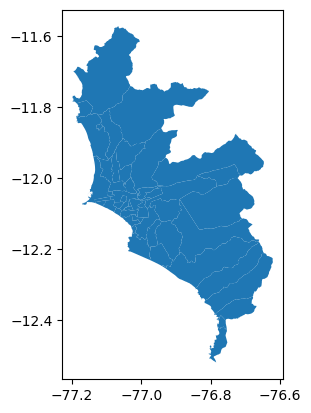

In [105]:
extracted_files = gpd.read_file('peru_districts.geojson')
extracted_files.plot()

## Búsqueda

In [106]:
def test_search_location(name):
    """Probar búsqueda de location por nombre"""
    conn = get_db_connection()
    cursor = conn.cursor()
    
    cursor.execute("""
        SELECT id, name, type, 
               ST_X(centroid) as lon, 
               ST_Y(centroid) as lat,
               get_location_full_path(id) as full_path
        FROM locations
        WHERE name_norm = %s
    """, (normalize_name(name),))
    
    results = cursor.fetchall()
    
    print(f"\nResultados para '{name}':")
    for row in results:
        print(f"  ID: {row[0]}, Nombre: {row[1]}, Tipo: {row[2]}")
        print(f"  Coordenadas: ({row[3]:.4f}, {row[4]:.4f})")
        print(f"  Path: {row[5]}\n")
    
    cursor.close()
    conn.close()

In [110]:
result = test_search_location('BEELLAVISTA')
result


Resultados para 'BEELLAVISTA':


In [115]:
def smart_search_location(search_input, country_code='PE', limit=10):
    """
    Búsqueda inteligente que maneja:
    - Typos (búsqueda fuzzy)
    - Búsquedas compuestas: "Lima, San Isidro" o "San Isidro, Lima"
    - Nombres parciales
    
    Args:
        search_input: String de búsqueda (puede ser compuesto)
        country_code: Código de país para filtrar (default: PE)
        limit: Número máximo de resultados
    
    Returns:
        Lista de tuplas (id, name, type, full_path, lat, lon, score)
    """
    conn = get_db_connection()
    cursor = conn.cursor()
    
    # Detectar si es búsqueda compuesta (contiene coma)
    if ',' in search_input:
        parts = [p.strip() for p in search_input.split(',')]
        
        # Búsqueda jerárquica: "distrito, ciudad"
        query = """
            WITH search_terms AS (
                SELECT 
                    unnest(%s::text[]) as term,
                    generate_series(1, %s) as term_order
            ),
            matched_locations AS (
                SELECT DISTINCT ON (l.id)
                    l.id,
                    l.name,
                    l.type,
                    l.path,
                    ST_Y(l.centroid) as latitude,
                    ST_X(l.centroid) as longitude,
                    get_location_full_path(l.id) as full_path,
                    nlevel(l.path) as specificity,
                    -- Score compuesto
                    (
                        -- Similitud del nombre principal
                        similarity(l.name_norm, normalize_name(st.term)) * 50 +
                        -- Bonus si coincide exacto
                        CASE WHEN l.name_norm = normalize_name(st.term) THEN 30 ELSE 0 END +
                        -- Bonus por tipo
                        CASE l.type
                            WHEN 'district' THEN 20
                            WHEN 'city' THEN 15
                            WHEN 'neighborhood' THEN 10
                            ELSE 5
                        END +
                        -- Penalización por distancia en orden de búsqueda
                        (5 - st.term_order) * 5
                    ) as match_score,
                    st.term_order
                FROM locations l
                CROSS JOIN search_terms st
                LEFT JOIN location_names ln ON ln.location_id = l.id
                WHERE 
                    (l.name_norm %% normalize_name(st.term) OR ln.name_norm %% normalize_name(st.term))
                    AND l.country_code = %s
            ),
            hierarchical_matches AS (
                SELECT 
                    m1.id,
                    m1.name,
                    m1.type,
                    m1.full_path,
                    m1.latitude,
                    m1.longitude,
                    -- Score total: suma de scores + bonus si hay relación jerárquica
                    COALESCE(SUM(m2.match_score), 0) +
                    CASE 
                        WHEN COALESCE(BOOL_OR(m1.path <@ m2.path OR m2.path <@ m1.path), false) THEN 50 
                        ELSE 0 
                    END as total_score
                FROM matched_locations m1
                LEFT JOIN matched_locations m2 ON m1.term_order != m2.term_order
                GROUP BY m1.id, m1.name, m1.type, m1.full_path, m1.latitude, m1.longitude, m1.path
            )
            SELECT 
                id, name, type, full_path, latitude, longitude, total_score
            FROM hierarchical_matches
            ORDER BY total_score DESC, name
            LIMIT %s;
        """
        
        cursor.execute(query, (parts, len(parts), country_code, limit))
        
    else:
        # Búsqueda simple con fuzzy matching
        query = """
            SELECT DISTINCT
                l.id,
                l.name,
                l.type,
                get_location_full_path(l.id) as full_path,
                ST_Y(l.centroid) as latitude,
                ST_X(l.centroid) as longitude,
                -- Score compuesto
                (
                    GREATEST(
                        similarity(l.name_norm, normalize_name(%s)) * 100,
                        COALESCE(MAX(similarity(ln.name_norm, normalize_name(%s))) * 100, 0)
                    ) +
                    CASE l.type
                        WHEN 'district' THEN 20
                        WHEN 'city' THEN 15
                        WHEN 'neighborhood' THEN 10
                        ELSE 5
                    END +
                    CASE WHEN l.name_norm = normalize_name(%s) THEN 30 ELSE 0 END
                ) as score
            FROM locations l
            LEFT JOIN location_names ln ON ln.location_id = l.id
            WHERE 
                (l.name_norm %% normalize_name(%s) OR ln.name_norm %% normalize_name(%s))
                AND l.country_code = %s
            GROUP BY l.id, l.name, l.type, l.centroid
            ORDER BY score DESC, l.name
            LIMIT %s;
        """
        
        cursor.execute(query, (
            search_input, search_input, search_input,
            search_input, search_input, country_code, limit
        ))
    
    results = cursor.fetchall()
    cursor.close()
    conn.close()
    
    return results

In [128]:
result = smart_search_location('Los, oLIVC0S')
result

[(28,
  'LOS OLIVOS',
  'district',
  'Perú > Lima > LOS OLIVOS',
  -11.972518649687355,
  -77.07437768975086,
  0.0)]

# Testing Modules

In [18]:
from app.services.geolocation.methods.aurora_db import smart_search_location
import json

In [25]:
result = smart_search_location('Lince')

In [ ]:
result

[(27,
  'LINCE',
  'district',
  'Perú > Lima > LINCE',
  -12.085769877547344,
  -77.0356913420741,
  '{"type":"MultiPolygon","coordinates":[[[[-77.028068121,-12.078711609],[-77.028051764,-12.078752587],[-77.028039697,-12.078782833],[-77.028026047,-12.078817056],[-77.027659922,-12.079734863],[-77.027608943,-12.079862652],[-77.027423309,-12.080328007],[-77.027371168,-12.080458712],[-77.027326262,-12.080571287],[-77.027004514,-12.081377849],[-77.026592805,-12.082409925],[-77.026178937,-12.083447413],[-77.025928562,-12.08407506],[-77.025629111,-12.084825728],[-77.025354504,-12.085514121],[-77.0252926,-12.085669298],[-77.025246191,-12.085785632],[-77.024776203,-12.086963804],[-77.024745629,-12.087040451],[-77.024679322,-12.087206671],[-77.024594434,-12.08741947],[-77.024477508,-12.087712579],[-77.02445351,-12.087772742],[-77.024353486,-12.08802348],[-77.024293185,-12.088129997],[-77.02411434,-12.088445913],[-77.024107607,-12.088457802],[-77.024052736,-12.08855473],[-77.023960709,-12.088705

In [33]:
result[0][3]

'Perú > Lima > LINCE'

In [ ]:
json.loads(result[0][6])['coordinates'] # <- Shape

[[[[-77.073638057, -11.917775888],
   [-77.073353381, -11.920522378],
   [-77.073324814, -11.920810724],
   [-77.073217465, -11.921894236],
   [-77.073154848, -11.922526267],
   [-77.07313507, -11.922738527],
   [-77.07308635, -11.92326147],
   [-77.07303948, -11.923764531],
   [-77.073037711, -11.923783523],
   [-77.073035215, -11.923813906],
   [-77.073034906, -11.923817663],
   [-77.073034254, -11.92382564],
   [-77.073033609, -11.923833452],
   [-77.073031057, -11.923864542],
   [-77.073030236, -11.92387454],
   [-77.07302252, -11.923968509],
   [-77.073015234, -11.924057224],
   [-77.073007785, -11.924147931],
   [-77.073007117, -11.924156048],
   [-77.073002891, -11.924207554],
   [-77.072998881, -11.924256363],
   [-77.072992664, -11.92433206],
   [-77.072991818, -11.924342368],
   [-77.072978445, -11.92450521],
   [-77.072963187, -11.924691005],
   [-77.072953541, -11.924808488],
   [-77.072950793, -11.924841972],
   [-77.072940016, -11.924973187],
   [-77.072932764, -11.925061

In [16]:
result = smart_search_location('lkdfgj')

# Implementación en flujo

## Location Slot Y Merging

In [4]:
from app.models.PropertyLead import PropertySearchParams
from app.services.geolocation.location_verifier import verify_location

In [5]:
valid_lead = PropertySearchParams.generate_valid_lead()
invalid_lead = PropertySearchParams.generate_invalid_lead()

In [6]:
new_lead = valid_lead.merge_with(invalid_lead)
new_lead.model_dump()

{'property_types': {'value': [<PropertyType.DEPARTAMENTO: 'departamento'>],
  'required': False,
  'state': <SlotState.VALIDATED: 'validated'>},
 'operation_types': {'value': <OperationType.ALQUILER: 'alquiler'>,
  'required': False,
  'state': <SlotState.VALIDATED: 'validated'>},
 'location': {'value': 'Los Olivos',
  'required': True,
  'geom': None,
  'state': <SlotState.PENDING_VALIDATION: 'pending_validation'>},
 'price': {'value': 1500.0,
  'required': False,
  'state': <SlotState.VALIDATED: 'validated'>},
 'area': {'value': 50.0,
  'required': False,
  'state': <SlotState.VALIDATED: 'validated'>},
 'bedroom_quantity': {'value': 2,
  'required': False,
  'state': <SlotState.VALIDATED: 'validated'>},
 'bathroom_quantity': {'value': 1,
  'required': False,
  'state': <SlotState.VALIDATED: 'validated'>}}

In [7]:
def run_verify_location(lead: PropertySearchParams):
    """Verify the location in the lead"""
    search_location: str = lead.location.value
    validation_status = lead.location.state.value

    # case 1: if there's no location inside the lead -> Nothing to do here
    if search_location == None:
        pass
    # case 2: if there's a location and it's already validated -> Nothing to do here
    elif search_location != None and validation_status == "validated":
        pass
    # case 3: if there's a location and it's NOT validated (pending_validation) -> Validate
    elif search_location != None and validation_status == "pending_validation":
        try:
            _, geometry = verify_location(search_location.lower())
            lead.location.geom = geometry
        except Exception as e:
            lead.location.geom = [999,]
    # case 4: if there's a location and the previous validation failed -> Nothing to do, let the query ask for a new location.
    elif search_location != None and validation_status == "validation_failed":
        pass
    
    return lead


In [8]:
verified_lead = run_verify_location(new_lead)

In [9]:
verified_lead.model_dump()

{'property_types': {'value': [<PropertyType.DEPARTAMENTO: 'departamento'>],
  'required': False,
  'state': <SlotState.VALIDATED: 'validated'>},
 'operation_types': {'value': <OperationType.ALQUILER: 'alquiler'>,
  'required': False,
  'state': <SlotState.VALIDATED: 'validated'>},
 'location': {'value': 'Los Olivos',
  'required': True,
  'geom': [[[[-77.073638057, -11.917775888],
     [-77.073353381, -11.920522378],
     [-77.073324814, -11.920810724],
     [-77.073217465, -11.921894236],
     [-77.073154848, -11.922526267],
     [-77.07313507, -11.922738527],
     [-77.07308635, -11.92326147],
     [-77.07303948, -11.923764531],
     [-77.073037711, -11.923783523],
     [-77.073035215, -11.923813906],
     [-77.073034906, -11.923817663],
     [-77.073034254, -11.92382564],
     [-77.073033609, -11.923833452],
     [-77.073031057, -11.923864542],
     [-77.073030236, -11.92387454],
     [-77.07302252, -11.923968509],
     [-77.073015234, -11.924057224],
     [-77.073007785, -11.924147

In [10]:
invalid_lead.location.value= 'asdfasdf'
invalid_lead.model_dump()

{'property_types': {'value': [<PropertyType.DEPARTAMENTO: 'departamento'>],
  'required': False,
  'state': <SlotState.VALIDATED: 'validated'>},
 'operation_types': {'value': None,
  'required': True,
  'state': <SlotState.MISSING: 'missing'>},
 'location': {'value': 'asdfasdf',
  'required': True,
  'geom': None,
  'state': <SlotState.PENDING_VALIDATION: 'pending_validation'>},
 'price': {'value': None,
  'required': True,
  'state': <SlotState.MISSING: 'missing'>},
 'area': {'value': 50.0,
  'required': False,
  'state': <SlotState.VALIDATED: 'validated'>},
 'bedroom_quantity': {'value': None,
  'required': False,
  'state': <SlotState.MISSING: 'missing'>},
 'bathroom_quantity': {'value': None,
  'required': False,
  'state': <SlotState.MISSING: 'missing'>}}

In [11]:
unverified_lead = run_verify_location(invalid_lead)

In [12]:
unverified_lead.model_dump()

{'property_types': {'value': [<PropertyType.DEPARTAMENTO: 'departamento'>],
  'required': False,
  'state': <SlotState.VALIDATED: 'validated'>},
 'operation_types': {'value': None,
  'required': True,
  'state': <SlotState.MISSING: 'missing'>},
 'location': {'value': 'asdfasdf',
  'required': True,
  'geom': [999],
  'state': <SlotState.VALIDATION_FAILED: 'validation_failed'>},
 'price': {'value': None,
  'required': True,
  'state': <SlotState.MISSING: 'missing'>},
 'area': {'value': 50.0,
  'required': False,
  'state': <SlotState.VALIDATED: 'validated'>},
 'bedroom_quantity': {'value': None,
  'required': False,
  'state': <SlotState.MISSING: 'missing'>},
 'bathroom_quantity': {'value': None,
  'required': False,
  'state': <SlotState.MISSING: 'missing'>}}

In [13]:
merged_lead = unverified_lead.merge_with(new_lead)
merged_lead.model_dump()

{'property_types': {'value': [<PropertyType.DEPARTAMENTO: 'departamento'>],
  'required': False,
  'state': <SlotState.VALIDATED: 'validated'>},
 'operation_types': {'value': <OperationType.ALQUILER: 'alquiler'>,
  'required': True,
  'state': <SlotState.VALIDATED: 'validated'>},
 'location': {'value': 'Los Olivos',
  'required': True,
  'geom': None,
  'state': <SlotState.PENDING_VALIDATION: 'pending_validation'>},
 'price': {'value': 1500.0,
  'required': True,
  'state': <SlotState.VALIDATED: 'validated'>},
 'area': {'value': 50.0,
  'required': False,
  'state': <SlotState.VALIDATED: 'validated'>},
 'bedroom_quantity': {'value': 2,
  'required': False,
  'state': <SlotState.VALIDATED: 'validated'>},
 'bathroom_quantity': {'value': 1,
  'required': False,
  'state': <SlotState.VALIDATED: 'validated'>}}

## Langchain Verification

In [14]:
from app.models.ChatState import MyState
from app.services.chatbot_langgraph import run_verify_location

In [15]:
my_state = MyState(
    user_message= 'test',
    message_history=[],
    input_lead = PropertySearchParams(), 
    input_state = dict(),
    extract_result = {
        'merged_lead': merged_lead   #<- change this
    },
    current_state_flow= [],
    new_search_flag= False
)

In [16]:
output_state = run_verify_location(my_state)

In [ ]:
output_state.extract_result.get('merged_lead').model_dump()  #<- works

{'property_types': {'value': [<PropertyType.DEPARTAMENTO: 'departamento'>],
  'required': False,
  'state': <SlotState.VALIDATED: 'validated'>},
 'operation_types': {'value': <OperationType.ALQUILER: 'alquiler'>,
  'required': True,
  'state': <SlotState.VALIDATED: 'validated'>},
 'location': {'value': 'Los Olivos',
  'required': True,
  'geom': [[[[-77.073638057, -11.917775888],
     [-77.073353381, -11.920522378],
     [-77.073324814, -11.920810724],
     [-77.073217465, -11.921894236],
     [-77.073154848, -11.922526267],
     [-77.07313507, -11.922738527],
     [-77.07308635, -11.92326147],
     [-77.07303948, -11.923764531],
     [-77.073037711, -11.923783523],
     [-77.073035215, -11.923813906],
     [-77.073034906, -11.923817663],
     [-77.073034254, -11.92382564],
     [-77.073033609, -11.923833452],
     [-77.073031057, -11.923864542],
     [-77.073030236, -11.92387454],
     [-77.07302252, -11.923968509],
     [-77.073015234, -11.924057224],
     [-77.073007785, -11.9241479